# 01 · Data Ingestion — IEA / Our World in Data

**Goal:** pull electric vehicle (EV) sales and market-share series for the Latin American
countries covered by this project, straight from the source the International Energy Agency
(IEA) publishes through Our World in Data (OWID).

**Coverage note (important):** OWID only reports these two series for **Brazil, Mexico,
Chile, and Colombia**. Peru, Argentina, Ecuador, and Bolivia are not broken out individually
in this source — their EV markets are likely too small to be reported separately by the IEA.
This is a genuine limitation of the source, not a bug in this notebook. See
`docs/data_sources.md` for how those four countries are instead covered qualitatively.

**Output:** `data/processed/iea_ev_sales_latam.csv` and `iea_ev_sales_share_latam.csv`.

In [8]:
import sys
sys.path.append('../src')
from utils import download_csv, save_processed, DATA_RAW, OWID_COUNTRIES
import pandas as pd
import matplotlib.pyplot as plt

## 1. Download raw series from Our World in Data

In [9]:
# OWID's "grapher" CSV endpoints. These are the stable, documented URLs —
# NOT a raw GitHub CSV path (an earlier draft of this project used a
# nonexistent GitHub URL that returned 404).
SALES_URL = "https://ourworldindata.org/grapher/electric-car-sales.csv"
SHARE_URL = "https://ourworldindata.org/grapher/electric-car-sales-share.csv"
QUERY_PARAMS = {"v": "1", "csvType": "full", "useColumnShortNames": "false"}

df_sales_raw = download_csv(SALES_URL, DATA_RAW / "iea_ev_sales_global.csv", params=QUERY_PARAMS)
df_share_raw = download_csv(SHARE_URL, DATA_RAW / "iea_ev_sales_share_global.csv", params=QUERY_PARAMS)

print(df_sales_raw.shape, df_share_raw.shape)
df_sales_raw.head()

14:13:22 | INFO | Downloading (attempt 1/3): https://ourworldindata.org/grapher/electric-car-sales.csv
14:13:22 | INFO | OK -> data/raw/iea_ev_sales_global.csv (823 rows)
14:13:22 | INFO | Downloading (attempt 1/3): https://ourworldindata.org/grapher/electric-car-sales-share.csv
14:13:23 | INFO | OK -> data/raw/iea_ev_sales_share_global.csv (817 rows)


(823, 4) (817, 4)


,Entity,Code,Year,Electric cars sold
0,Australia,AUS,2011,49
1,Australia,AUS,2012,250
2,Australia,AUS,2013,290
3,Australia,AUS,2014,1320
4,Australia,AUS,2015,1760


## 2. Filter to the project's target countries

We check which target countries actually exist in the source before filtering, so a silent
mismatch (e.g. a renamed country) doesn't quietly produce an empty dataset.

In [10]:
available_countries = sorted(df_sales_raw['Entity'].unique())
missing = [c for c in OWID_COUNTRIES if c not in available_countries]

print(f"Target countries present in the source: {len(OWID_COUNTRIES) - len(missing)} / {len(OWID_COUNTRIES)}")
if missing:
    print(f"Not reported individually by this source: {missing}")
    print("(Expected — see the coverage note above and docs/data_sources.md)")

Target countries present in the source: 4 / 8
Not reported individually by this source: ['Peru', 'Argentina', 'Ecuador', 'Bolivia']
(Expected — see the coverage note above and docs/data_sources.md)


In [11]:
df_sales_latam = df_sales_raw[df_sales_raw['Entity'].isin(OWID_COUNTRIES)].copy()
df_share_latam = df_share_raw[df_share_raw['Entity'].isin(OWID_COUNTRIES)].copy()

print(f"Sales (LatAm subset): {df_sales_latam.shape}")
print(f"Share (LatAm subset): {df_share_latam.shape}")
df_share_latam.tail(10)

Sales (LatAm subset): (61, 4)
Share (LatAm subset): (61, 4)


,Entity,Code,Year,Share of new cars that are electric
460,Mexico,MEX,2016,0.056
461,Mexico,MEX,2017,0.091
462,Mexico,MEX,2018,0.150
463,Mexico,MEX,2019,0.150
464,Mexico,MEX,2020,0.490
465,Mexico,MEX,2021,0.780
466,Mexico,MEX,2022,0.960
467,Mexico,MEX,2023,1.500
468,Mexico,MEX,2024,2.200
469,Mexico,MEX,2025,7.000


## 3. Save cleaned datasets for downstream notebooks

In [12]:
save_processed(df_sales_latam, "iea_ev_sales_latam.csv")
save_processed(df_share_latam, "iea_ev_sales_share_latam.csv")

14:13:23 | INFO | Saved -> data/processed/iea_ev_sales_latam.csv (61 rows, 4 cols)
14:13:23 | INFO | Saved -> data/processed/iea_ev_sales_share_latam.csv (61 rows, 4 cols)


PosixPath('/Users/davidanampa/Documents/3. Data Analyst projects/latam-automotive-analytics/data/processed/iea_ev_sales_share_latam.csv')

## 4. Quick visual sanity check

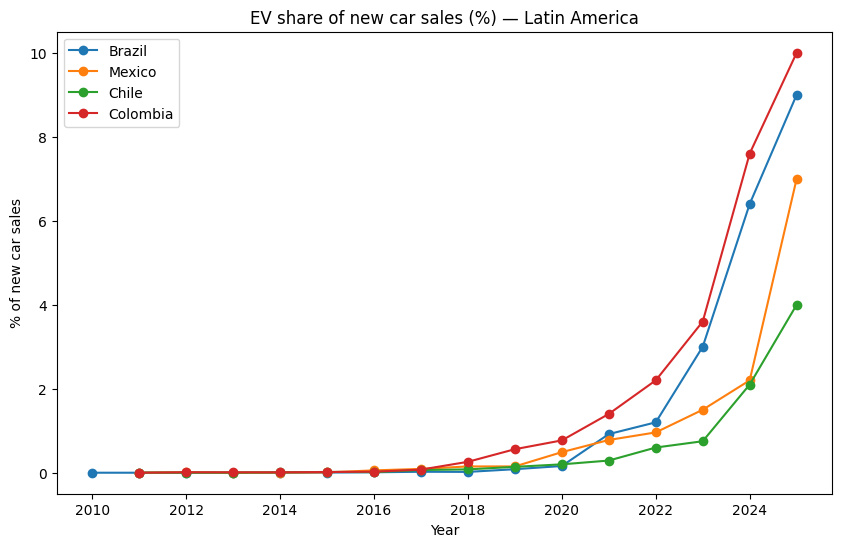

In [13]:
value_col = [col for col in df_share_latam.columns if col not in ('Entity','Code','Year')][0]

fig, ax = plt.subplots(figsize=(10, 6))
for country in OWID_COUNTRIES:
    subset = df_share_latam[df_share_latam['Entity'] == country].sort_values('Year')
    if len(subset) > 0:
        ax.plot(subset['Year'], subset[value_col], marker='o', label=country)

ax.set_title("EV share of new car sales (%) — Latin America")
ax.set_xlabel("Year")
ax.set_ylabel("% of new car sales")
ax.legend()
plt.show()

## Findings

As of the latest year available (2025), EV share of new car sales in the four IEA-covered
countries is: **Colombia leads at 10%**, followed by Brazil (9%), Mexico (7%), and Chile (4%).
All four show a consistent upward trend rather than a noisy one (confirmed statistically in
notebook 05).

**Business takeaway:** Colombia and Brazil are the two markets where EV adoption is furthest
along — relevant for prioritizing where a distribution, service, or parts-supply operation
would find the largest existing customer base today, versus Chile and Mexico where the
opportunity is more about being early.

**Limitation to keep in mind:** Peru, Argentina, Ecuador, and Bolivia are not part of this
comparison because the IEA does not report them individually (see the coverage note above).
This does not mean those markets are inactive — see `docs/data_sources.md` and the executive
summary notebook (07) for sourced context on Peru and Ecuador specifically.